<a href="https://colab.research.google.com/github/youkjang/gefs-heavy-precip-verification/blob/main/02_probability_of_heavy_precipitation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NOAA GEFS Precipitation

- Ensemble Mean Precipitation
- Probability of heavy precipitation
- Thresholds for probability map: 10mm, 25mm, 30mm

##1.Install packages

In [1]:
!pip -q install "eccodes>=2.37.0" cfgrib s3fs "fsspec==2025.3.0"

In [2]:
!pip install cartopy

###2.Import Libraries

In [3]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import s3fs
from pathlib import Path

In [4]:
import cartopy.crs as ccrs

###3.Set GEFS case information
- control + 10 perturbed memebrs

In [5]:
init_date = "20260520"   # YYYYMMDD
cycle = "00"             # GEFS cycle: 00, 06, 12, 18 UTC
fhr = 24                 # forecast hour

members = ["c00"] + [f"p{i:02d}" for i in range(1, 11)]

threshold_mm = 25.0

cache_dir = Path("/content/gefs_precip_cache")
cache_dir.mkdir(exist_ok=True)

Path("figures").mkdir(exist_ok=True)

fs = s3fs.S3FileSystem(anon=True)

##4.Function to open one GEFS precipitation member

In [6]:
def open_gefs_precip_member(init_date, cycle, member, fhr):
    """
    Open GEFS accumulated precipitation for one member and one forecast hour.

    Parameters
    ----------
    init_date : str
        Forecast initialization date, format YYYYMMDD.
    cycle : str
        Forecast cycle: "00", "06", "12", or "18".
    member : str
        GEFS member, e.g., "c00", "p01", "p02".
    fhr : int
        Forecast hour.

    Returns
    -------
    xarray.DataArray
        Accumulated precipitation over CONUS in mm.
    """

    fname = f"ge{member}.t{cycle}z.pgrb2a.0p50.f{fhr:03d}"

    s3_key = (
        f"noaa-gefs-pds/gefs.{init_date}/{cycle}/atmos/pgrb2ap5/"
        f"{fname}"
    )

    local_file = cache_dir / fname

    if not local_file.exists():
        print(f"Downloading {fname}")
        fs.get(s3_key, str(local_file))
    else:
        print(f"Using cached file: {fname}")

    ds = xr.open_dataset(
        local_file,
        engine="cfgrib",
        backend_kwargs={
            "filter_by_keys": {
                "typeOfLevel": "surface",
                "stepType": "accum"
            },
            "indexpath": ""
        }
    )

    if "tp" not in ds.data_vars:
        raise ValueError(f"'tp' not found. Available variables: {list(ds.data_vars)}")

    precip = ds["tp"]

    # Convert longitude from 0–360 to -180–180
    precip = precip.assign_coords(
        longitude=((precip.longitude + 180) % 360) - 180
    ).sortby("longitude")

    # Subset CONUS
    if precip.latitude[0] > precip.latitude[-1]:
        precip_us = precip.sel(
            longitude=slice(-125, -66),
            latitude=slice(50, 24)
        )
    else:
        precip_us = precip.sel(
            longitude=slice(-125, -66),
            latitude=slice(24, 50)
        )

    precip_us = precip_us.squeeze()
    precip_us.attrs["units"] = "mm"
    precip_us.attrs["long_name"] = "Accumulated precipitation"

    return precip_us

##5.Load multiple ensemble members

In [7]:
precip_members = []

for member in members:
    print(f"Opening member: {member}")

    da = open_gefs_precip_member(
        init_date=init_date,
        cycle=cycle,
        member=member,
        fhr=fhr
    )

    da = da.expand_dims(member=[member])
    precip_members.append(da)

precip_ens = xr.concat(precip_members, dim="member")


Opening member: c00
Using cached file: gec00.t00z.pgrb2a.0p50.f024
Opening member: p01
Using cached file: gep01.t00z.pgrb2a.0p50.f024
Opening member: p02
Using cached file: gep02.t00z.pgrb2a.0p50.f024
Opening member: p03
Using cached file: gep03.t00z.pgrb2a.0p50.f024
Opening member: p04
Using cached file: gep04.t00z.pgrb2a.0p50.f024
Opening member: p05
Using cached file: gep05.t00z.pgrb2a.0p50.f024
Opening member: p06
Using cached file: gep06.t00z.pgrb2a.0p50.f024
Opening member: p07
Using cached file: gep07.t00z.pgrb2a.0p50.f024
Opening member: p08
Using cached file: gep08.t00z.pgrb2a.0p50.f024
Opening member: p09
Using cached file: gep09.t00z.pgrb2a.0p50.f024
Opening member: p10
Using cached file: gep10.t00z.pgrb2a.0p50.f024


/tmp/ipykernel_11573/2354021617.py:16: FutureWarning: In a future version of xarray the default value for coords will change from coords='different' to coords='minimal'. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set coords explicitly.
  precip_ens = xr.concat(precip_members, dim="member")


In [8]:
precip_ens.member, precip_ens.latitude, precip_ens.longitude

(<xarray.DataArray 'member' (member: 11)> Size: 88B
 array(['c00', 'p01', 'p02', 'p03', 'p04', 'p05', 'p06', 'p07', 'p08', 'p09',
        'p10'], dtype=object)
 Coordinates:
   * member      (member) object 88B 'c00' 'p01' 'p02' ... 'p08' 'p09' 'p10'
     number      (member) int64 88B 0 1 2 3 4 5 6 7 8 9 10
     time        datetime64[ns] 8B 2026-05-20
     step        timedelta64[ns] 8B 1 days
     surface     float64 8B 0.0
     valid_time  datetime64[ns] 8B 2026-05-21,
 <xarray.DataArray 'latitude' (latitude: 53)> Size: 424B
 array([50. , 49.5, 49. , 48.5, 48. , 47.5, 47. , 46.5, 46. , 45.5, 45. , 44.5,
        44. , 43.5, 43. , 42.5, 42. , 41.5, 41. , 40.5, 40. , 39.5, 39. , 38.5,
        38. , 37.5, 37. , 36.5, 36. , 35.5, 35. , 34.5, 34. , 33.5, 33. , 32.5,
        32. , 31.5, 31. , 30.5, 30. , 29.5, 29. , 28.5, 28. , 27.5, 27. , 26.5,
        26. , 25.5, 25. , 24.5, 24. ])
 Coordinates:
   * latitude    (latitude) float64 424B 50.0 49.5 49.0 48.5 ... 25.0 24.5 24.0
     time   

##6.Compute ensemble mean precipitation

In [9]:
precip_mean = precip_ens.mean(dim="member")

precip_mean.attrs["units"] = "mm"
precip_mean.attrs["long_name"] = "GEFS ensemble mean accumulated precipitation"

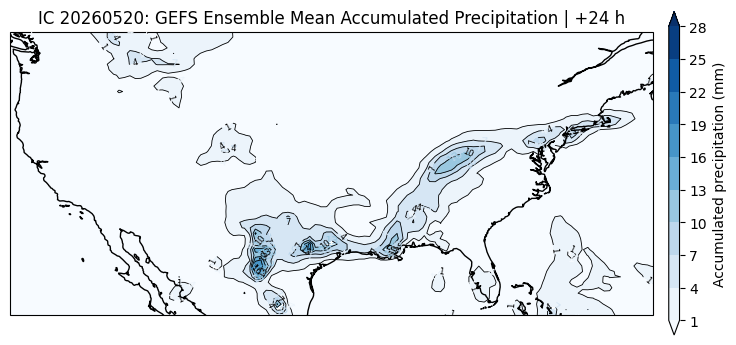

In [10]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))


plot_var = precip_mean

contour_levels_temp = np.arange(1, 30, 3)
cs_temp = ax.contourf(plot_var.longitude, plot_var.latitude, plot_var,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Blues', extend='both')
cs_temp_contour = ax.contour(plot_var.longitude, plot_var.latitude, plot_var,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          colors='black',linewidths=0.6)
ax.clabel(
    cs_temp_contour,
    inline=True,
    fontsize=6,
    colors='black',
    fmt='%g')

ax.coastlines()
plt.clabel(cs_temp, inline=True, fontsize=8, fmt='%1.0f')

# Add title and colorbar, then show the plot
plt.title(f"IC {init_date}: GEFS Ensemble Mean Accumulated Precipitation | +{fhr} h")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.colorbar(cs_temp, label="Accumulated precipitation (mm)",
             pad=0.02, aspect=30,shrink=0.7)

plt.savefig("gefs_precip_ensemble_mean_24h.png", dpi=150, bbox_inches="tight")

plt.show()

##7.Compute probablity of heavy precipitation

In [11]:
heavy_event = precip_ens >= threshold_mm
prob_heavy = heavy_event.mean(dim="member") * 100.0

prob_heavy.attrs["units"] = "%"
prob_heavy.attrs["long_name"] = f"Probability of precipitation ≥ {threshold_mm} mm"

##8.Plot probability map

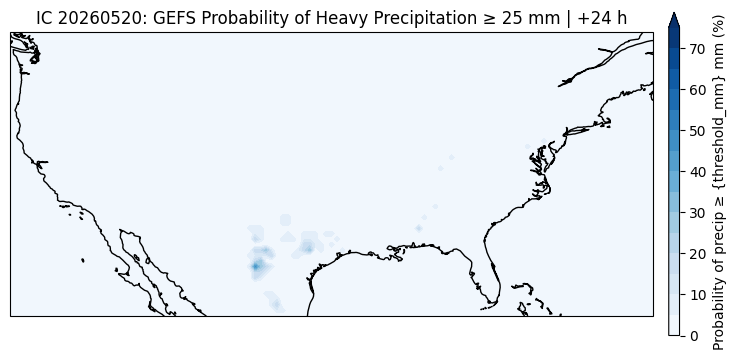

In [12]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))


plot_var = prob_heavy

contour_levels_temp = np.arange(0, 80, 5)
cs_temp = ax.contourf(plot_var.longitude, plot_var.latitude, plot_var,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Blues', extend='max')
#cs_temp_contour = ax.contour(plot_var.longitude, plot_var.latitude, plot_var,
#                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
#                          colors='black',linewidths=0.6)
ax.clabel(
    cs_temp_contour,
    inline=True,
    fontsize=6,
    colors='black',
    fmt='%g')

ax.coastlines()
#plt.clabel(cs_temp, inline=True, fontsize=8, fmt='%1.0f')

# Add title and colorbar, then show the plot
plt.title(f"IC {init_date}: GEFS Probability of Heavy Precipitation ≥ {threshold_mm:.0f} mm | +{fhr} h")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.colorbar(cs_temp, label="Probability of precip ≥ {threshold_mm} mm (%)",
             pad=0.02, aspect=30,shrink=0.7)

#plt.savefig("gefs_probability_heavy_precip_25mm_24h.png", dpi=150, bbox_inches="tight")

plt.show()

##9.Add a simple maximum probability check

In [13]:
max_prob = float(prob_heavy.max().values)
mean_prob = float(prob_heavy.mean().values)

print(f"Maximum probability of precipitation ≥ {threshold_mm} mm: {max_prob:.1f}%")
print(f"Domain-mean probability of precipitation ≥ {threshold_mm} mm: {mean_prob:.1f}%")

Maximum probability of precipitation ≥ 25.0 mm: 45.5%
Domain-mean probability of precipitation ≥ 25.0 mm: 0.1%


##10.Compare different thresholds

In [14]:
thresholds = [10.0, 25.0, 50.0]

prob_maps = {}

for thresh in thresholds:
    prob_maps[thresh] = (precip_ens >= thresh).mean(dim="member") * 100.0

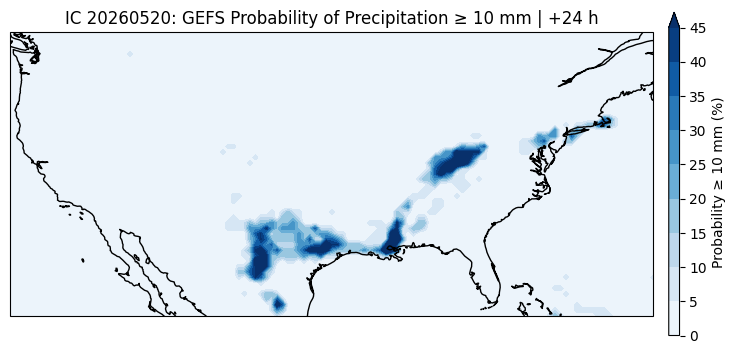

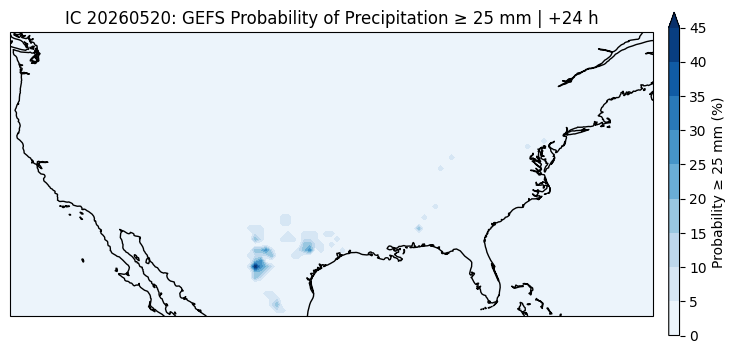

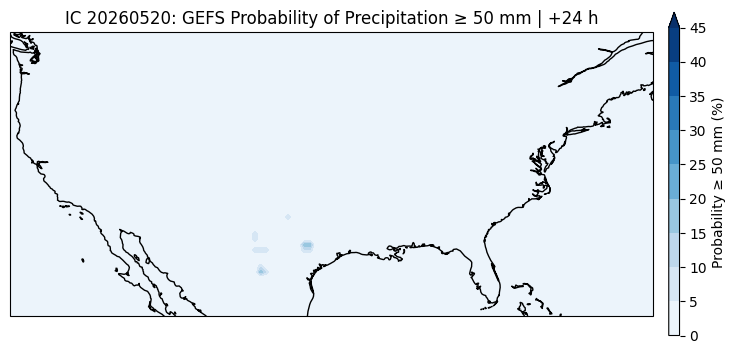

In [15]:
for thresh, prob in prob_maps.items():
    #plt.figure(figsize=(9, 5))
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(10,6))

    contour_levels_temp = np.arange(0, 50, 5)
    cs_temp = ax.contourf(prob.longitude, prob.latitude, prob,
                          levels=contour_levels_temp, transform=ccrs.PlateCarree(),
                          cmap='Blues', extend='max')
    # cs_temp_contour = ax.contour(prob.longitude, prob.latitude, prob,
    #                       levels=contour_levels_temp, transform=ccrs.PlateCarree(),
    #                       colors='black',linewidths=0.6)
    ax.clabel(
        cs_temp_contour,
        inline=True,
        fontsize=6,
        colors='black',
         fmt='%g')

    ax.coastlines()
    #plt.clabel(cs_temp, inline=True, fontsize=8, fmt='%1.0f')

    plt.title(f"IC {init_date}: GEFS Probability of Precipitation ≥ {thresh:.0f} mm | +{fhr} h")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")

    plt.colorbar(cs_temp, label=f"Probability ≥ {thresh:.0f} mm (%)",
             pad=0.02, aspect=30,shrink=0.7)

    #plt.tight_layout()

    plt.savefig(f"figures/gefs_probability_precip_{int(thresh)}mm_24h.png", dpi=150, bbox_inches="tight")
    plt.show()
    #plt.savefig(f"gefs_probability_precip_threshhold_24h.png", dpi=150, bbox_inches="tight")
    #plt.show()

## Note on AI Assistance

ChatGPT was used as a coding assistant for drafting and debugging portions of the Python workflow.
All scientific decisions, code review, and testing were performed by me.